In [1]:
!pip install tabpfn --no-index --find-links=file:///kaggle/input/pip-packages-icr/pip-packages
!mkdir -p /opt/conda/lib/python3.10/site-packages/tabpfn/models_diff
!cp /kaggle/input/pip-packages-icr/pip-packages/prior_diff_real_checkpoint_n_0_epoch_100.cpkt /opt/conda/lib/python3.10/site-packages/tabpfn/models_diff/

Looking in links: file:///kaggle/input/pip-packages-icr/pip-packages
Processing /kaggle/input/pip-packages-icr/pip-packages/tabpfn-0.1.9-py3-none-any.whl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline
import seaborn as sns
import gc
import re as re
from collections import Counter

from tqdm.auto import tqdm
import math
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

import time
import xgboost
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from catboost import Pool, CatBoostClassifier
from tabpfn import TabPFNClassifier
from sklearn.metrics import log_loss

from matplotlib import pyplot
%matplotlib inline
tqdm.pandas()

rc = {
    "axes.facecolor": "#FFF9ED",
    "figure.facecolor": "#FFF9ED",
    "axes.edgecolor": "#000000",
    "grid.color": "#EBEBE7",
    "font.family": "serif",
    "axes.labelcolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "grid.alpha": 0.4
}

sns.set(rc=rc)

from colorama import Style, Fore
red = Style.BRIGHT + Fore.RED
blu = Style.BRIGHT + Fore.BLUE
mgt = Style.BRIGHT + Fore.MAGENTA
gld = Style.BRIGHT + Fore.YELLOW
res = Style.RESET_ALL

In [3]:
train             = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')
test              = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/test.csv')
greeks            = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/greeks.csv')
sample_submission = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv')

# Test prg

In [4]:
# select numerical and categorical variables respectively.
num_cols = test.select_dtypes(include=['float64']).columns.tolist()
cat_cols = test.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Id')

In [5]:
from sklearn import preprocessing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.manifold import TSNE
import umap
import umap.plot

# Combine numeric and categorical features
FEATURES = num_cols + cat_cols

# https://stackoverflow.com/questions/43232506/using-pipeline-with-custom-classes-in-sklearn

class Preproc():
    def __init__(self):
        self.scaler = StandardScaler()
        self.imputer_median = SimpleImputer(strategy='median')
        self.imputer_knn = KNNImputer(n_neighbors=4)
        self.encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')

    def fit(self, X):
        
        X_nan = X[num_cols].isna()
        
        self.imputer_median = self.imputer_median.fit(X[num_cols])
        numeric_df_tmp = pd.DataFrame(self.imputer_median.transform(X[num_cols]), columns=num_cols)
        
        self.scaler = self.scaler.fit(numeric_df_tmp)
        scaled_numeric_df_tmp = pd.DataFrame(self.scaler.transform(numeric_df_tmp), columns=num_cols)
        
        X_nan.index = scaled_numeric_df_tmp.index
        scaled_numeric_df_tmp[num_cols] = scaled_numeric_df_tmp[num_cols].where(X_nan[num_cols]==False, np.nan)
        
        self.imputer_knn = self.imputer_knn.fit(scaled_numeric_df_tmp)

        self.encoder = self.encoder.fit(X[cat_cols])
        
        return self

    def transform(self, X):
        try:
            X_nan = X[num_cols].isna()
            numeric_df_tmp = pd.DataFrame(self.imputer_median.transform(X[num_cols]), columns=num_cols)
            scaled_numeric_df_tmp = pd.DataFrame(self.scaler.transform(numeric_df_tmp), columns=num_cols)
            X_nan.index = scaled_numeric_df_tmp.index
            scaled_numeric_df_tmp[num_cols] = scaled_numeric_df_tmp[num_cols].where(X_nan[num_cols]==False, np.nan)
            scaled_numeric_df = pd.DataFrame(self.imputer_knn.transform(scaled_numeric_df_tmp), columns=num_cols)
            encoded_cat_df = pd.DataFrame(self.encoder.transform(X[cat_cols]), columns=self.encoder.get_feature_names_out(cat_cols))
            processed_df = pd.concat([scaled_numeric_df, encoded_cat_df], axis=1)
        except Exception as err:
            print('Preproc.transform(): {}'.format(err))
        return processed_df
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [6]:
from sklearn.model_selection import StratifiedKFold, train_test_split
class StratifiedKFold3(StratifiedKFold):

    def split(self, X, y, groups=None):
        s = super().split(X, y, groups)
        s = list(s)
        for i in range(len(s)):
            if i == (len(s) - 1):
                test_indxs = s[i][1]
                cv_indxs = s[0][1]
                train_indxs = [m for m in s[i][0] if m not in cv_indxs]   
            else:
                test_indxs = s[i][1]
                cv_indxs = s[i+1][1]
                train_indxs = [m for m in s[i][0] if m not in cv_indxs]

            yield train_indxs, cv_indxs, test_indxs
                        
def balanced_log_loss_3(y_true, y_pred):
    # y_true: correct labels 0, 1
    # y_pred: predicted probabilities of class=1
    y_true = y_true.astype(int)
    # calculate the number of observations for each class
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    # calculate the weights for each class to balance classes
    w_0 = 1 / N_0
    w_1 = 1 / N_1
    # calculate the predicted probabilities for each class
    p = np.clip(y_pred, 1e-15, 1 - 1e-15)
    # calculate the summed log loss for each class
    log_loss_0 = -np.sum((1 - y_true) * np.log(p[:, 0]))
    log_loss_1 = -np.sum(y_true * np.log(p[:, 1]))
    # calculate the weighted summed logarithmic loss
    # (factgor of 2 included to give same result as LL with balanced input)
    balanced_log_loss = 2*(w_0 * log_loss_0 + w_1 * log_loss_1) / (w_0 + w_1)
    # return the average log loss
    return balanced_log_loss/(N_0+N_1)

def competition_log_loss(y_true, y_pred):
    # y_true: correct labels 0, 1
    # y_pred: predicted probabilities of class=1
    # Implements the Evaluation equation with w_0 = w_1 = 1.
    # Calculate the number of observations for each class
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    # Calculate the predicted probabilities for each class
    p = np.clip(y_pred, 1e-15, 1 - 1e-15)
    # Calculate the average log loss for each class
    log_loss_0 = -1 / N_0 * np.sum((1 - y_true) * np.log(p[:, 0]))
    log_loss_1 = -1 / N_1 * np.sum(y_true * np.log(p[:, 1]))
    # return the (not further weighted) average of the averages
    return (log_loss_0 + log_loss_1)/2

def competition_log_loss_opt(y_true, y_pred):
    # y_true: correct labels 0, 1
    # y_pred: predicted probabilities of class=1
    # Implements the Evaluation equation with w_0 = w_1 = 1.
    # Calculate the number of observations for each class
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    # Calculate the predicted probabilities for each class
    p = np.clip(y_pred, 1e-15, 1 - 1e-15)
    # Calculate the average log loss for each class
    log_loss_0 = -1 / N_0 * np.sum((1 - y_true) * np.log(1 - p))
    log_loss_1 = -1 / N_1 * np.sum(y_true * np.log(p))
    # return the (not further weighted) average of the averages
    return (log_loss_0 + log_loss_1)/2

In [7]:
def competition_log_loss_lgb(y_true, y_pred):
    N_0 = np.sum(1 - y_true)
    N_1 = np.sum(y_true)
    p_1 = np.clip(y_pred, 1e-15, 1 - 1e-15)
    p_0 = 1 - p_1
    log_loss_0 = -np.sum((1 - y_true) * np.log(p_0)) / N_0
    log_loss_1 = -np.sum(y_true * np.log(p_1)) / N_1
    return (log_loss_0 + log_loss_1)/2

def lgb_metric(y_true, y_pred):
    return 'balanced_log_loss', competition_log_loss_lgb(y_true, y_pred), False

def predict_proba_multy(model, X):
    p = model.predict_proba(X)
    class_0_est_instances = p[:,0].sum()
    others_est_instances = p[:,1:].sum()
    new_p = p * np.array([[1/(class_0_est_instances if i==0 else others_est_instances) for i in range(p.shape[1])]])
    return new_p / np.sum(new_p,axis=1,keepdims=1)

In [8]:
# XGBoostClassifier
from sklearn.utils import class_weight

XGB_params = {"tree_method":'exact',
"n_estimators": 100,
"n_jobs": -1,
"verbosity": 0,
"random_state":42, 
'learning_rate': 0.09502482005870472, 
'max_depth': 4, 
'subsample': 0.7978078500565327, 
'colsample_bytree': 0.732835163413311, 
'min_child_weight': 5, 
'scale_pos_weight': 4.417261890014011}

In [9]:
# LGBMClassifier
# LGBM_params={
#     'n_estimators': 90, 
#     'max_depth': 3, 
#     'learning_rate': 0.05, 
#     'min_child_weight': 5, 
#     'min_child_samples': 40, 
#     'subsample': 0.8,
#     'subsample_freq': 1,
#     'colsample_bytree': 0.8,
#     'random_state':42
# }

In [10]:
# CatBoostClassifier
# CTB_params={
#     'n_estimators': 90, 
#     'max_depth': 5, 
#     'learning_rate': 0.1, 
#     'min_child_weight': 10, 
#     'min_child_samples': 20, 
#     'subsample': 0.8,
#     'subsample_freq': 1,
#     'colsample_bytree': 0.9,
#     'random_state':42
# }

In [39]:
XGB_params = {"tree_method":'exact',
                "n_estimators": 100,
                "n_jobs": -1,
                "verbosity": 0,
                "random_state":42, 
                'learning_rate': 0.09502482005870472, 
                'max_depth': 4, 
                'subsample': 0.7978078500565327, 
                'colsample_bytree': 0.732835163413311, 
                'min_child_weight': 5, 
                'scale_pos_weight': 4.417261890014011}
# LGBMClassifier
LGB_params = {'task': 'train', 
               'objective': 'binary', 
               'boosting_type': 'gbdt', 
               'num_iterations': 100, 
               'deterministic': True, 
               'metric': 'binary_logloss',
               'class_weight': 'balanced', 
               'is_unbalance': False, 
               'scale_pos_weight': 4.365400792083353,
               'subsample': 0.9703964667364557, 
               'colsample_bytree': 0.8522574991127007, 
               'learning_rate': 0.07356332135622914, 
               'num_leaves': 15, 
               'min_child_samples': 52, 
               'max_bin': 10}

# CatBoost params
CTB_params = {'objective': 'Logloss', 
            'iterations': 100, 
            'random_seed': 0, 
            'eval_metric': 'Logloss', 
            'boosting_type': 'Plain', 
            'grow_policy': 'Depthwise', 
            'class_weights': None, 
            'scale_pos_weight': 7.189402024415567, 
            'learning_rate': 0.0703334430380961, 
            'subsample': 0.6373683470191154, 
            'random_strength': 1.4194042148863577, 
            'min_data_in_leaf': 49, 
            'fold_len_multiplier': 1.7070420011629888}

######################## Training FOLD 1 ########################


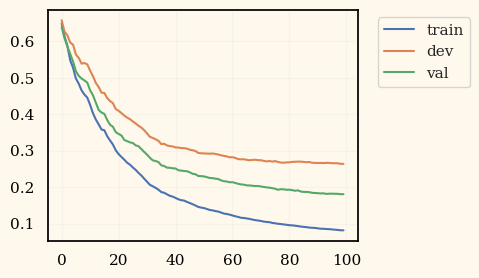

                     BLL train XGB: 0.05710       
                     BLL dev XGB: 0.31605       
                     BLL val XGB: 0.18909       


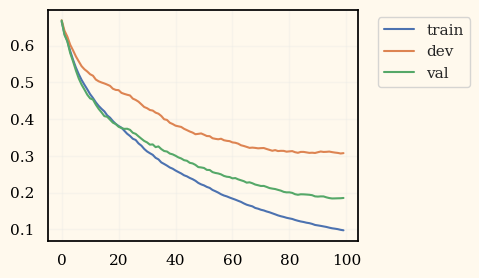

                     BLL train LGBM: 0.09749       
                     BLL dev LGBM: 0.30766       
                     BLL val LGBM: 0.18553       


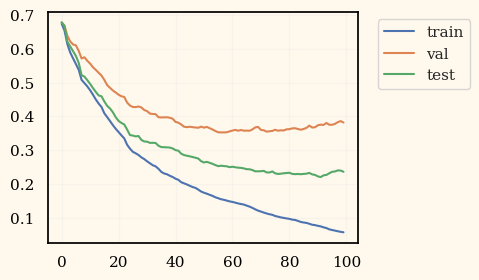

                     BLL train ctb: 0.07825       
                     BLL dev ctb: 0.33932       
                     BLL val ctb: 0.20947       
######################## Training FOLD 2 ########################


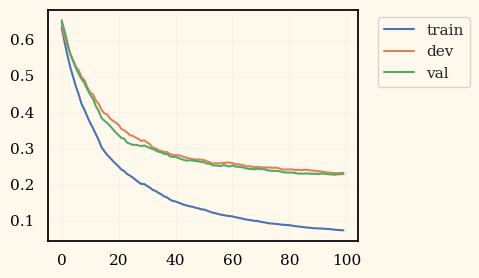

                     BLL train XGB: 0.04994       
                     BLL dev XGB: 0.30345       
                     BLL val XGB: 0.30797       


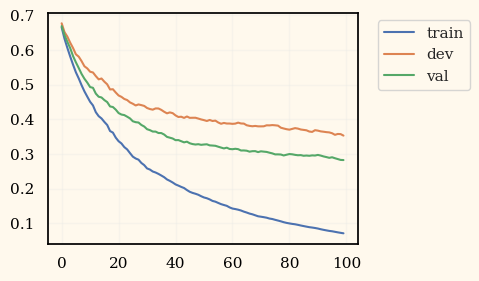

                     BLL train LGBM: 0.07158       
                     BLL dev LGBM: 0.35336       
                     BLL val LGBM: 0.28283       


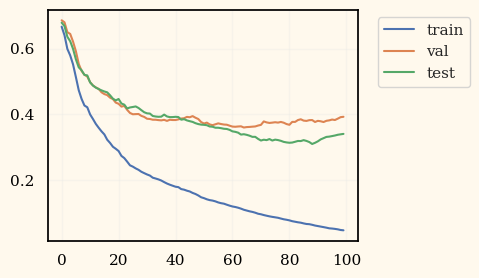

                     BLL train ctb: 0.06721       
                     BLL dev ctb: 0.34682       
                     BLL val ctb: 0.28210       
######################## Training FOLD 3 ########################


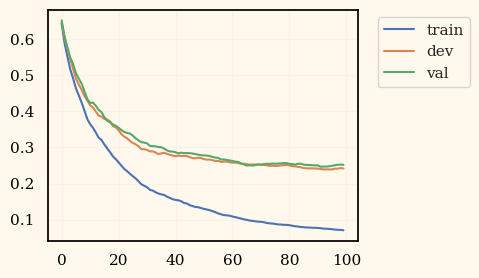

                     BLL train XGB: 0.04908       
                     BLL dev XGB: 0.32713       
                     BLL val XGB: 0.31096       


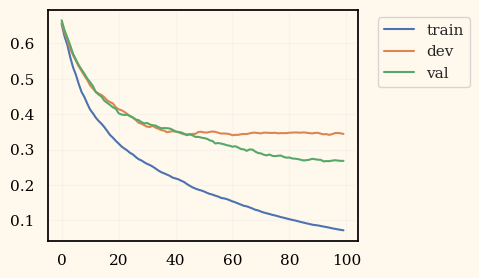

                     BLL train LGBM: 0.07153       
                     BLL dev LGBM: 0.34407       
                     BLL val LGBM: 0.26798       


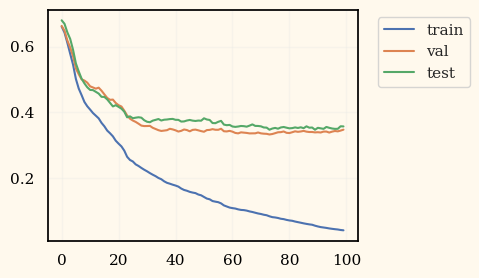

                     BLL train ctb: 0.05697       
                     BLL dev ctb: 0.31590       
                     BLL val ctb: 0.31513       
######################## Training FOLD 4 ########################


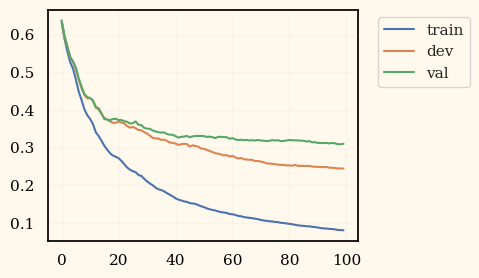

                     BLL train XGB: 0.05612       
                     BLL dev XGB: 0.30459       
                     BLL val XGB: 0.38460       


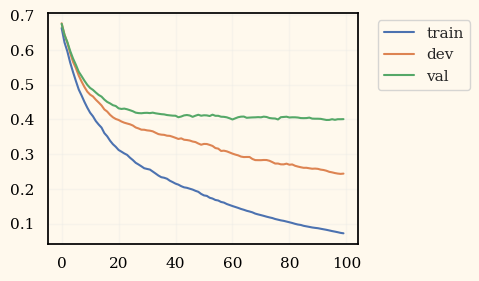

                     BLL train LGBM: 0.07237       
                     BLL dev LGBM: 0.24417       
                     BLL val LGBM: 0.40099       


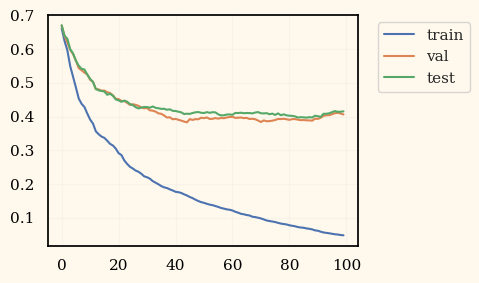

                     BLL train ctb: 0.07268       
                     BLL dev ctb: 0.35549       
                     BLL val ctb: 0.36655       
######################## Training FOLD 5 ########################


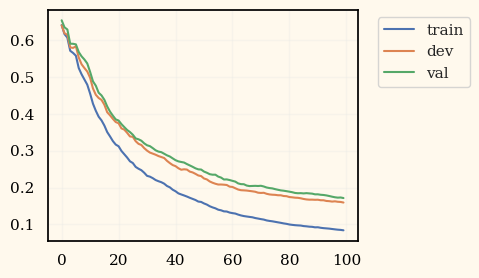

                     BLL train XGB: 0.05888       
                     BLL dev XGB: 0.14387       
                     BLL val XGB: 0.18817       


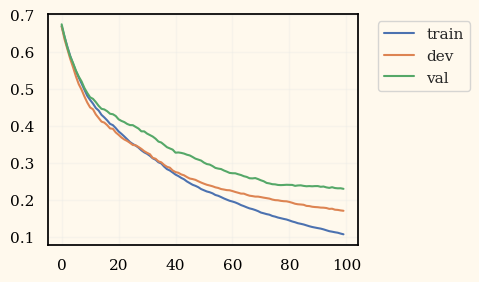

                     BLL train LGBM: 0.10610       
                     BLL dev LGBM: 0.16969       
                     BLL val LGBM: 0.22902       


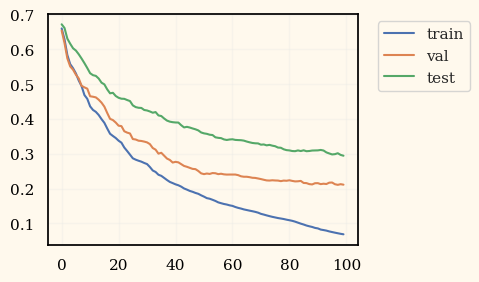

                     BLL train ctb: 0.07255       
                     BLL dev ctb: 0.19960       
                     BLL val ctb: 0.27892       
*********************************************


In [40]:
FOLDS = 5
SEED = 1004

### OOFs
xgb_models = []
xgb_oof_train = []
xgb_oof_dev = []
xgb_oof_val = []
###
lgbm_models = []
lgbm_oof_train = []
lgbm_oof_dev = []
lgbm_oof_val = []
###
ctb_models = []
ctb_oof_train = []
ctb_oof_dev = []
ctb_oof_val = []
###
tab_models = []
tab_oof_train = []
tab_oof_dev = []
tab_oof_val = []

### Scores
train_scores_xgb = []
dev_scores_xgb = []
val_scores_xgb = []
###
train_scores_lgbm = []
dev_scores_lgbm = []
val_scores_lgbm = []
###
train_scores_ctb = []
dev_scores_ctb = []
val_scores_ctb = []
###
train_scores_tab = []
dev_scores_tab = []
val_scores_tab = []

### Losses
train_loss_xgb = []
dev_loss_xgb = []
val_loss_xgb = []
###
train_loss_lgbm = []
dev_loss_lgbm = []
val_loss_lgbm = []
###
train_loss_ctb = []
dev_loss_ctb = []
val_loss_ctb = []
###
train_loss_tab = []
dev_loss_tab = []
val_loss_tab = []

###
models1 = []
models2 = []
models3 = []
models4 = []
###

counter = 1
X = train[FEATURES]
y = train['Class']
# y_alpha = greeks['Alpha']
# unique_classes, y_alpha = np.unique(y_alpha, return_inverse=True)
# y_alpha = pd.Series(y_alpha)
# y_bin = y

skf = StratifiedKFold3(n_splits=FOLDS, shuffle=True, random_state=SEED)
for fold, (train_idx, dev_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f'{"#"*24} Training FOLD {fold+1} {"#"*24}')
    preproc = Preproc()
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    weights = class_weight.compute_sample_weight('balanced', y_train)
    X_train = preproc.fit_transform(X_train)
    
    X_dev, y_dev = X.iloc[dev_idx], y.iloc[dev_idx]
    X_dev = preproc.transform(X_dev)
    
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    X_val = preproc.transform(X_val)
    
    watchlist = [(X_train, y_train), (X_dev, y_dev),(X_val, y_val)]
    
    # XGB model
    model1 = XGBClassifier(**XGB_params)
    model1.fit(X_train, y_train, sample_weight=weights, eval_set=watchlist, early_stopping_rounds=None, verbose=0)
    models1.append(model1)
    
    train_preds = model1.predict_proba(X_train)
    dev_preds = model1.predict_proba(X_dev)
    val_preds = model1.predict_proba(X_val)
    
    train_score = competition_log_loss(y_train, train_preds)
    dev_score = competition_log_loss(y_dev, dev_preds)
    val_score = competition_log_loss(y_val, val_preds)
    
    train_scores_xgb.append(train_score)
    dev_scores_xgb.append(dev_score)
    val_scores_xgb.append(val_score)
    
    best_iter = model1.best_iteration
    results_xgb = model1.evals_result()

    plt.figure(figsize=(4,3))
    pyplot.plot(results_xgb['validation_0']['logloss'], label='train')
    pyplot.plot(results_xgb['validation_1']['logloss'], label='dev')
    pyplot.plot(results_xgb['validation_2']['logloss'], label='val')
    
    train_loss_xgb.append(results_xgb['validation_0']['logloss'][best_iter])
    dev_loss_xgb.append(results_xgb['validation_1']['logloss'][best_iter])
    val_loss_xgb.append(results_xgb['validation_2']['logloss'][best_iter])
    
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    pyplot.show()
    
    idx_pred_target_train = np.vstack([train_idx,  train_preds[:, 1], y_train]).T
    idx_pred_target_dev = np.vstack([dev_idx,  dev_preds[:, 1], y_dev]).T
    idx_pred_target_val = np.vstack([val_idx,  val_preds[:, 1], y_val]).T

    print(f'{" "*20} BLL train XGB: {train_score:.5f} {" "*6}')
    print(f'{" "*20} BLL dev XGB: {dev_score:.5f} {" "*6}')
    print(f'{" "*20} BLL val XGB: {val_score:.5f} {" "*6}')

    xgb_oof_train.append(idx_pred_target_train)
    xgb_oof_dev.append(idx_pred_target_dev)
    xgb_oof_val.append(idx_pred_target_val)
    
    # LGBM model
#     model2 = lgb.LGBMClassifier(**LGBM_params)
    model2 = lgb.LGBMClassifier(**LGB_params)
    
#     model2.fit(X_train, y_train, sample_weight=weights, eval_set=watchlist, early_stopping_rounds=None, verbose=0)
    model2.fit(X_train, y_train, eval_set=watchlist, verbose=1000, eval_metric=lgb_metric)
    models2.append(model2)
    
    train_preds = model2.predict_proba(X_train)
    dev_preds = model2.predict_proba(X_dev)
    val_preds = model2.predict_proba(X_val)
    
    train_score = competition_log_loss(y_train, train_preds)
    dev_score = competition_log_loss(y_dev, dev_preds)
    val_score = competition_log_loss(y_val, val_preds)
    
    train_scores_lgbm.append(train_score)
    dev_scores_lgbm.append(dev_score)
    val_scores_lgbm.append(val_score)
    
    results_lgbm = model2.evals_result_

    plt.figure(figsize=(4,3))
    pyplot.plot(results_lgbm['training']['balanced_log_loss'], label='train')
    pyplot.plot(results_lgbm['valid_1']['balanced_log_loss'], label='dev')
    pyplot.plot(results_lgbm['valid_2']['balanced_log_loss'], label='val')
    
    train_loss_lgbm.append(model2. best_score_['training']['balanced_log_loss'])
    dev_loss_lgbm.append(model2. best_score_['valid_1']['balanced_log_loss'])
    val_loss_lgbm.append(model2. best_score_['valid_2']['balanced_log_loss'])
    
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    pyplot.show()
    
    idx_pred_target_train = np.vstack([train_idx,  train_preds[:, 1], y_train]).T
    idx_pred_target_dev = np.vstack([dev_idx,  dev_preds[:, 1], y_dev]).T
    idx_pred_target_val = np.vstack([val_idx,  val_preds[:, 1], y_val]).T

    print(f'{" "*20} BLL train LGBM: {train_score:.5f} {" "*6}')
    print(f'{" "*20} BLL dev LGBM: {dev_score:.5f} {" "*6}')
    print(f'{" "*20} BLL val LGBM: {val_score:.5f} {" "*6}')

    lgbm_oof_train.append(idx_pred_target_train)
    lgbm_oof_dev.append(idx_pred_target_dev)
    lgbm_oof_val.append(idx_pred_target_val)

    # CatBoost model
#     model3 = LGBMClassifier(**CTB_params)
    model3 = CatBoostClassifier(**CTB_params)
    model3.fit(X_train, y_train,  eval_set=watchlist, verbose = 0)
    
#     model3 = XGBClassifier(**CTB_params)
#     model3.fit(X_train, y_train, sample_weight=weights, eval_set=watchlist, early_stopping_rounds=None, verbose=0)
    models3.append(model3)
    
    train_preds = model3.predict_proba(X_train)
    dev_preds = model3.predict_proba(X_dev)
    val_preds = model3.predict_proba(X_val)
    
    train_score = competition_log_loss(y_train, train_preds)
    dev_score = competition_log_loss(y_dev, dev_preds)
    val_score = competition_log_loss(y_val, val_preds)
    
    train_scores_ctb.append(train_score)
    dev_scores_ctb.append(dev_score)
    val_scores_ctb.append(val_score)
    
    results_ctb = model3.evals_result_

    plt.figure(figsize=(4,3))
    pyplot.plot(results_ctb['validation_0']['Logloss'], label='train')
    pyplot.plot(results_ctb['validation_1']['Logloss'], label='val')
    pyplot.plot(results_ctb['validation_2']['Logloss'], label='test')
    
    train_loss_ctb.append(model3. best_score_['validation_0']['Logloss'])
    dev_loss_ctb.append(model3. best_score_['validation_1']['Logloss'])
    val_loss_ctb.append(model3. best_score_['validation_2']['Logloss'])
    
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    pyplot.show()
    
    idx_pred_target_train = np.vstack([train_idx,  train_preds[:, 1], y_train]).T
    idx_pred_target_dev = np.vstack([dev_idx,  dev_preds[:, 1], y_dev]).T
    idx_pred_target_val = np.vstack([val_idx,  val_preds[:, 1], y_val]).T

    print(f'{" "*20} BLL train ctb: {train_score:.5f} {" "*6}')
    print(f'{" "*20} BLL dev ctb: {dev_score:.5f} {" "*6}')
    print(f'{" "*20} BLL val ctb: {val_score:.5f} {" "*6}')

    ctb_oof_train.append(idx_pred_target_train)
    ctb_oof_dev.append(idx_pred_target_dev)
    ctb_oof_val.append(idx_pred_target_val)
    
#     model4 = TabPFNClassifier(N_ensemble_configurations=46,device='cuda:0')
#     y_alpha_train = y_alpha[train_idx]
#     y_alpha_dev = y_alpha[dev_idx]
#     y_alpha_val = y_alpha[val_idx]

#     model4.fit(X_train, y_alpha_train, overwrite_warning=True)
#     models4.append(model4)
    
#     train_preds = predict_proba_multy(model4, X_train)
#     dev_preds = predict_proba_multy(model4, X_dev)
#     val_preds = predict_proba_multy(model4, X_val)
    
#     log_loss_train = log_loss(y_alpha_train,train_preds)
#     log_loss_dev = log_loss(y_alpha_dev,dev_preds)
#     log_loss_val = log_loss(y_alpha_val,val_preds)
    
#     train_loss_tab.append(log_loss_train)
#     dev_loss_tab.append(log_loss_dev)
#     val_loss_tab.append(log_loss_val)
    
#     train_preds = np.concatenate((train_preds[:,:1], np.sum(train_preds[:,1:], 1, keepdims=True)), axis=1)
#     dev_preds = np.concatenate((dev_preds[:,:1], np.sum(dev_preds[:,1:], 1, keepdims=True)), axis=1)
#     val_preds = np.concatenate((val_preds[:,:1], np.sum(val_preds[:,1:], 1, keepdims=True)), axis=1)
    

#     # Apply weights in the log_loss
#     train_score = competition_log_loss(y_bin[train_idx], train_preds)
#     dev_score = competition_log_loss(y_bin[dev_idx], dev_preds)
#     val_score = competition_log_loss(y_bin[val_idx], val_preds)
    
#     train_scores_tab.append(train_score)
#     dev_scores_tab.append(dev_score)
#     val_scores_tab.append(val_score)
    
#     idx_pred_target_train = np.vstack([train_idx,  train_preds[:, 1], y_bin[train_idx]]).T
#     idx_pred_target_dev = np.vstack([dev_idx,  dev_preds[:, 1], y_bin[dev_idx]]).T
#     idx_pred_target_val = np.vstack([val_idx,  val_preds[:, 1], y_bin[val_idx]]).T
    
#     tab_oof_train.append(idx_pred_target_train)
#     tab_oof_dev.append(idx_pred_target_dev)
#     tab_oof_val.append(idx_pred_target_val)
#     # xgb_oof_test
    
#     print(log_loss_train,log_loss_dev,log_loss_val)
#     print(train_score,dev_score,val_score)
    
print('*'*45)

# from sklearn.metrics import roc_auc_score
# # Compute AUC for each fold
# auc_scores_train = [roc_auc_score(oof[:, 2], oof[:, 1]) for oof in xgb_oof_train]
# auc_scores_dev = [roc_auc_score(oof[:, 2], oof[:, 1]) for oof in xgb_oof_dev]
# auc_scores_val = [roc_auc_score(oof[:, 2], oof[:, 1]) for oof in xgb_oof_val]

# # Plot AUC scores
# plt.figure(figsize=(4,3))
# plt.plot(range(1, FOLDS+1), auc_scores_train, marker='o', label="auc_scores_train")
# plt.plot(range(1, FOLDS+1), auc_scores_dev, marker='o', label="auc_scores_dev")
# plt.plot(range(1, FOLDS+1), auc_scores_val, marker='o', label="auc_scores_val")
# plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
# plt.title('AUC for each fold')
# plt.xlabel('Fold')
# plt.ylabel('AUC')
# plt.grid(True)
# plt.show()

# print(f'XGB Loss mean/std for train/dev/val:')
# print(f'XGB BLL mean/std for train/dev/val:')
# print('XGB AUC train mean/std dev mean/std val mean/std:')

# print(f'{np.mean(train_loss):.3f} {np.std(train_loss):.3f} \
# {np.mean(train_scores):.3f} {np.std(train_scores):.3f} \
# {np.mean(dev_loss):.3f} {np.std(dev_loss):.3f} \
# {np.mean(dev_scores):.3f} {np.std(dev_scores):.3f} \
# {np.mean(val_loss):.3f} {np.std(val_loss):.3f} \
# {np.mean(val_scores):.3f} {np.std(val_scores):.3f} \
# {(np.mean(val_scores) + 1.96 * np.std(val_scores) / math.sqrt(FOLDS)):.3f}'.replace('.', ','))

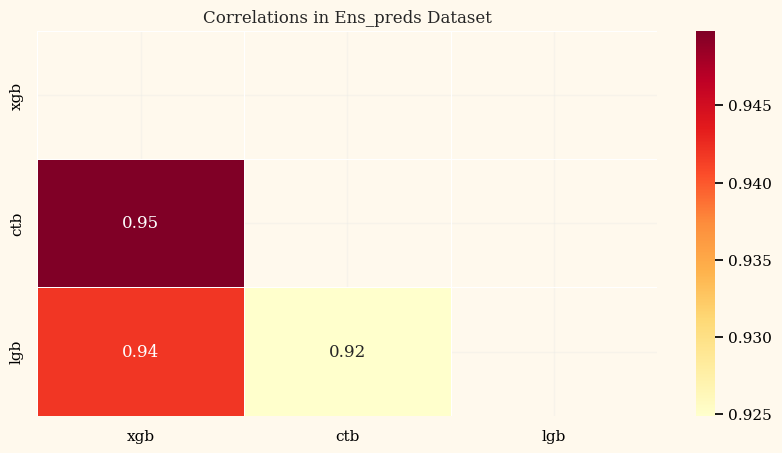

In [41]:
xgb_oof_dev_clean = pd.DataFrame(np.concatenate(xgb_oof_dev, axis=0))
lgbm_oof_dev_clean = pd.DataFrame(np.concatenate(lgbm_oof_dev, axis=0))
ctb_oof_dev_clean = pd.DataFrame(np.concatenate(ctb_oof_dev, axis=0))
# tab_oof_dev_clean = pd.DataFrame(np.concatenate(tab_oof_dev, axis=0))

# ens_preds = pd.concat([xgb_oof_dev_clean[1], lgbm_oof_dev_clean[1], ctb_oof_dev_clean[1], tab_oof_dev_clean[1]], axis = 1)
# ens_preds.columns=['xgb', 'lgb', 'ctb', 'tab']
ens_preds = pd.concat([xgb_oof_dev_clean[1], lgbm_oof_dev_clean[1], ctb_oof_dev_clean[1]], axis = 1)
ens_preds.columns=['xgb', 'lgb', 'ctb']


def plot_top_correlations(df: pd.core.frame.DataFrame, n: int, title_name: str='Top Correlations') -> None:
    # Calculate correlation between all variables
    corr = df.corr()

    # Select variables having highest absolute correlation
    top_corr_cols = corr.abs().nlargest(n, columns=corr.columns).index
    top_corr = corr.loc[top_corr_cols, top_corr_cols]

    fig, axes = plt.subplots(figsize=(10, 5))
    mask = np.zeros_like(top_corr)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(top_corr, mask=mask, linewidths=.5, cmap='YlOrRd', annot=True)
    plt.title(title_name)
    plt.show()

# Plot heatmap of top 12 correlations in training data
plot_top_correlations(ens_preds, 3, 'Correlations in Ens_preds Dataset')

In [42]:
# https://stackoverflow.com/questions/41090791/how-do-i-optimize-and-find-the-coefficients-for-two-equations-simultaneously-in
from scipy.optimize import minimize

xgb_oof_dev_clean = pd.DataFrame(np.concatenate(xgb_oof_dev, axis=0))
lgbm_oof_dev_clean = pd.DataFrame(np.concatenate(lgbm_oof_dev, axis=0))
ctb_oof_dev_clean = pd.DataFrame(np.concatenate(ctb_oof_dev, axis=0))
# tab_oof_dev_clean = pd.DataFrame(np.concatenate(tab_oof_dev, axis=0))

def func1(params):
    a, b, c = params
    y_pred_vote = (xgb_oof_dev_clean[1] * a + lgbm_oof_dev_clean[1] * b + ctb_oof_dev_clean[1] * c) / (a + b + c)
    return competition_log_loss_opt(xgb_oof_dev_clean[2], y_pred_vote)

# choose reasonable values for your 3 parameters here, i.e. close to the "right" answer, this may take a few tries
first_guess = [0.25, 0.5, 0.25]  

#Optimizer
res = minimize(func1, first_guess)
best_fit = res.x

coeffs = best_fit / sum(best_fit)
print(coeffs)

[ 0.57988245  0.44280401 -0.02268645]


In [43]:
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.2722814212858907
        x: [ 5.929e-01  4.527e-01 -2.320e-02]
      nit: 12
      jac: [ 8.941e-07 -1.222e-06 -1.069e-06]
 hess_inv: [[ 3.388e+01 -1.342e+01 -7.574e+00]
            [-1.342e+01  8.753e+00 -1.445e+00]
            [-7.574e+00 -1.445e+00  1.165e+01]]
     nfev: 56
     njev: 14

In [54]:
import numpy as np

from scipy.optimize import rosen, differential_evolution

def func_difopt(x):
    y_pred_vote = (xgb_oof_dev_clean[1] * x[0] + lgbm_oof_dev_clean[1] * x[1] + ctb_oof_dev_clean[1] * x[2]) / (x[0] + x[1] + x[2])
    return competition_log_loss_opt(xgb_oof_dev_clean[2], y_pred_vote)

bounds = [(-1, 1), (-1, 1), (-1, 1)]

result = differential_evolution(func_difopt, bounds, seed=1)

best_fit = result.x

coeffs = best_fit / sum(best_fit)

print(coeffs)

[ 0.57948222  0.44308073 -0.02256295]


In [52]:
result

 message: Optimization terminated successfully.
 success: True
     fun: 0.2722814237167058
       x: [-6.595e-01 -5.043e-01  2.568e-02]
     nit: 8
    nfev: 425
     jac: [ 5.868e-06 -7.871e-06 -3.975e-06]

In [ ]:
train_scores_weighed = []
dev_scores_weighed = []
val_scores_weighed = []

X = train[FEATURES]
y = train['Class']
ens_preds['Weighted_pred'] = ens_preds['xgb']*coeffs[0] + ens_preds['lgb']*coeffs[1] + ens_preds['ctb']*coeffs[2]
ens_preds.index = xgb_oof_dev_clean[0].astype(int)
weighted_preds = ens_preds['Weighted_pred']

for fold, (train_idx, dev_idx, val_idx) in enumerate(skf.split(X, y)):
    
    y_train, y_dev, y_val = y.iloc[train_idx], y.iloc[dev_idx], y.iloc[val_idx]
    train_preds, dev_preds,val_preds = weighted_preds.iloc[train_idx], weighted_preds.iloc[dev_idx], weighted_preds.iloc[val_idx]
    
    train_score = competition_log_loss_opt(y_train, train_preds)
    train_scores_weighed.append(train_score)
    dev_score = competition_log_loss_opt(y_dev, dev_preds)
    dev_scores_weighed.append(dev_score)
    val_score = competition_log_loss_opt(y_val, val_preds)
    val_scores_weighed.append(val_score)
    
    print(f'{" "*20} BLL train weighted: {train_score:.5f} {" "*6}')
    print(f'{" "*20} BLL dev weighted: {dev_score:.5f} {" "*6}')
    print(f'{" "*20} BLL val weighted: {val_score:.5f} {" "*6}')

print(f'{np.mean(train_scores_weighed):.3f} {np.std(train_scores_weighed):.3f} \
    {np.mean(dev_scores_weighed):.3f} {np.std(dev_scores_weighed):.3f} \
    {np.mean(val_scores_weighed):.3f} {np.std(val_scores_weighed):.3f} \
    {(np.mean(val_scores_weighed) + 1.96 * np.std(val_scores_weighed) / math.sqrt(FOLDS)):.3f}'.replace('.', ','))

In [ ]:
# Submission
# p1 = np.zeros(len(test), dtype='float32').reshape((len(test), 1))
# p2 = np.zeros(len(test), dtype='float32').reshape((len(test), 1))
# p3 = np.zeros(len(test), dtype='float32').reshape((len(test), 1))

res = np.zeros(len(test), dtype='float32').reshape((len(test), 1))

# XGB preds

X_test = test[FEATURES]
X_test = preproc.transform(X_test)

for i in range(FOLDS):
    probs_m1 = models1[i].predict_proba(X_test)
    probs_m2 = models2[i].predict_proba(X_test)
    probs_m3 = models3[i].predict_proba(X_test)
    probs_ens = coeffs[0]*probs_m1 + coeffs[1]*probs_m2 + coeffs[2]*probs_m3
    res+= probs_ens[:,:1]
    
p = res/FOLDS
  
# for model in models1:
#     X_test = test[FEATURES]
#     X_test = preproc.transform(X_test)
#     probabilities = model.predict_proba(X_test)
#     p1 += probabilities[:,:1]
# p1 = p1/FOLDS

# # LGBM preds
# for model in models2:
#     X_test = test[FEATURES]
#     X_test = preproc.transform(X_test)
#     probabilities = model.predict_proba(X_test)
#     p2 += probabilities[:,:1]
# p2 = p2/FOLDS

# # CTB preds
# for model in models3:
#     X_test = test[FEATURES]
#     X_test = preproc.transform(X_test)
#     probabilities = model.predict_proba(X_test)
#     p3 += probabilities[:,:1]

# p3 = p3/FOLDS

# p = coeffs[0]*p1 + coeffs[1]*p2 + coeffs[2]*p3

submission = pd.DataFrame(test["Id"], columns=["Id"])
submission["class_0"] = p
submission["class_1"] = 1 - p
submission.to_csv('submission.csv', index=False)

# submission_df = pd.read_csv('submission.csv')
# submission_df